In [14]:
!pip install -q tiktoken datasets pandas matplotlib psutil

In [15]:
import os
import time
import math
import json
import random
import shutil
import subprocess
import threading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import tiktoken
from datasets import load_dataset

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    print("CUDA:", torch.version.cuda)
    print("PyTorch:", torch.__version__)

Device: cuda
GPU: NVIDIA RTX 6000 Ada Generation
VRAM GB: 47.98779296875
CUDA: 12.1
PyTorch: 2.5.1+cu121


In [16]:
# CELL 3 — Updated config for Experiment 18: Large Scaling + 15k Training

RUN_NAME = "logos_exp18_large_scaling_weight_tying_swiglu_15k_train"

OUT_DIR = Path("./logos_runs") / RUN_NAME
DATA_DIR = Path("./data")

OUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

DATA_CACHE = DATA_DIR / "openwebtext_subset_100k.txt"

# Data
OWT_SAMPLES = 100_000

# Model
# Same architecture as Experiments 14, 15, 16, and 17
BATCH_SIZE = 32
BLOCK_SIZE = 512
N_EMBD = 768
N_HEAD = 12
N_LAYER = 12
DROPOUT = 0.2

# SwiGLU hidden size
SWIGLU_HIDDEN = int((8 * N_EMBD) / 3)

# Training
# Main change from Experiment 17:
# MAX_ITERS: 10000 → 15000
MAX_ITERS = 15000
EVAL_INTERVAL = 1000
EVAL_ITERS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.1
GRAD_CLIP = 1.0
WARMUP_ITERS = 400
MIN_LR_RATIO = 0.05

# Generation
GENERATE_TOKENS = 250
TEMPERATURE = 0.9
TOP_K = 40
TOP_P = 0.9

BEST_MODEL_PATH = OUT_DIR / "logos_large_scaling_weight_tying_swiglu_15k_train_best.pt"
METRICS_PATH = OUT_DIR / "large_scaling_weight_tying_swiglu_15k_train_metrics.csv"
SUMMARY_PATH = OUT_DIR / "large_scaling_weight_tying_swiglu_15k_train_summary.json"

config = {
    "run_name": RUN_NAME,
    "experiment_type": "large_scaling_weight_tying_swiglu_15k_train",
    "seed": SEED,
    "owt_samples": OWT_SAMPLES,
    "batch_size": BATCH_SIZE,
    "block_size": BLOCK_SIZE,
    "tokens_per_step": BATCH_SIZE * BLOCK_SIZE,
    "n_embd": N_EMBD,
    "n_head": N_HEAD,
    "head_dim": N_EMBD // N_HEAD,
    "n_layer": N_LAYER,
    "dropout": DROPOUT,
    "ffn_type": "SwiGLU",
    "swiglu_hidden": SWIGLU_HIDDEN,
    "normalization": "LayerNorm",
    "weight_tying": True,
    "scaling_phase": True,
    "scale_level": "large",
    "extended_training": True,
    "training_stage": "15k_iterations",
    "max_iters": MAX_ITERS,
    "eval_interval": EVAL_INTERVAL,
    "eval_iters": EVAL_ITERS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "grad_clip": GRAD_CLIP,
    "warmup_iters": WARMUP_ITERS,
    "min_lr_ratio": MIN_LR_RATIO,
    "generate_tokens": GENERATE_TOKENS,
    "temperature": TEMPERATURE,
    "top_k": TOP_K,
    "top_p": TOP_P,
}

print(json.dumps(config, indent=2))

{
  "run_name": "logos_exp18_large_scaling_weight_tying_swiglu_15k_train",
  "experiment_type": "large_scaling_weight_tying_swiglu_15k_train",
  "seed": 42,
  "owt_samples": 100000,
  "batch_size": 32,
  "block_size": 512,
  "tokens_per_step": 16384,
  "n_embd": 768,
  "n_head": 12,
  "head_dim": 64,
  "n_layer": 12,
  "dropout": 0.2,
  "ffn_type": "SwiGLU",
  "swiglu_hidden": 2048,
  "normalization": "LayerNorm",
  "weight_tying": true,
  "scaling_phase": true,
  "scale_level": "large",
  "extended_training": true,
  "training_stage": "15k_iterations",
  "max_iters": 15000,
  "eval_interval": 1000,
  "eval_iters": 50,
  "learning_rate": 0.0003,
  "weight_decay": 0.1,
  "grad_clip": 1.0,
  "warmup_iters": 400,
  "min_lr_ratio": 0.05,
  "generate_tokens": 250,
  "temperature": 0.9,
  "top_k": 40,
  "top_p": 0.9
}


In [17]:
# CELL 4 — Load OpenWebText subset without clean filtering

if not DATA_CACHE.exists():
    print("Downloading OpenWebText subset...")
    
    dataset = load_dataset("openwebtext", split="train", streaming=True)
    
    samples = []
    
    for i, sample in enumerate(dataset):
        if i >= OWT_SAMPLES:
            break
        
        text_piece = sample.get("text", "")
        
        if isinstance(text_piece, str) and len(text_piece.strip()) > 100:
            samples.append(text_piece.strip())
    
    text = "\n\n".join(samples)
    
    with open(DATA_CACHE, "w", encoding="utf-8") as f:
        f.write(text)
    
    print(f"Saved {len(samples)} samples to {DATA_CACHE}")

else:
    print("Loading cached original OpenWebText subset...")
    
    with open(DATA_CACHE, "r", encoding="utf-8") as f:
        text = f.read()

print("Characters:", len(text))
print("\nPreview:\n")
print(text[:500])

Loading cached original OpenWebText subset...
Characters: 492672887

Preview:

Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.

CNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the B


In [18]:
enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab

def encode(s):
    return enc.encode_ordinary(s)

def decode(ids):
    return enc.decode(ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print("Vocab size:", vocab_size)
print("Total tokens:", len(data))
print("Train tokens:", len(train_data))
print("Val tokens:", len(val_data))

assert len(train_data) > BLOCK_SIZE + 1
assert len(val_data) > BLOCK_SIZE + 1

Vocab size: 50257
Total tokens: 113063536
Train tokens: 101757182
Val tokens: 11306354


In [19]:
def get_batch(split):
    source = train_data if split == "train" else val_data
    
    ix = torch.randint(
        low=0,
        high=len(source) - BLOCK_SIZE - 1,
        size=(BATCH_SIZE,)
    )
    
    x = torch.stack([source[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([source[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    
    return x.to(device), y.to(device)

xb, yb = get_batch("train")

print("x shape:", xb.shape)
print("y shape:", yb.shape)

x shape: torch.Size([32, 512])
y shape: torch.Size([32, 512])


In [20]:
# CELL 7 — GPT-style decoder-only model for Experiment 18: Large Scaling + 15k Training

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, dropout):
        super().__init__()

        assert n_embd % n_head == 0

        self.n_head = n_head
        self.head_dim = n_embd // n_head

        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = dropout
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        q, k, v = self.qkv(x).split(C, dim=2)

        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        y = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True
        )

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.proj(y))

        return y


class SwiGLUFeedForward(nn.Module):
    def __init__(self, n_embd, hidden_dim, dropout):
        super().__init__()

        self.gate_proj = nn.Linear(n_embd, hidden_dim)
        self.up_proj = nn.Linear(n_embd, hidden_dim)
        self.down_proj = nn.Linear(hidden_dim, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        gate = F.silu(self.gate_proj(x))
        value = self.up_proj(x)

        x = gate * value
        x = self.down_proj(x)
        x = self.dropout(x)

        return x


class TransformerBlock(nn.Module):
    def __init__(self, n_embd, n_head, dropout, swiglu_hidden):
        super().__init__()

        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, dropout)

        self.ln2 = nn.LayerNorm(n_embd)
        self.ffn = SwiGLUFeedForward(n_embd, swiglu_hidden, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class LogosLargeScaling15KTrainLM(nn.Module):
    def __init__(self):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding = nn.Embedding(BLOCK_SIZE, N_EMBD)

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(N_EMBD, N_HEAD, DROPOUT, SWIGLU_HIDDEN)
                for _ in range(N_LAYER)
            ]
        )

        self.ln_f = nn.LayerNorm(N_EMBD)

        # Output head without bias for clean weight tying.
        self.lm_head = nn.Linear(N_EMBD, vocab_size, bias=False)

        self.apply(self._init_weights)

        # Weight tying:
        # Output projection shares the same tensor as token embedding.
        self.lm_head.weight = self.token_embedding.weight

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding(idx)

        pos = torch.arange(T, device=idx.device)
        pos_emb = self.position_embedding(pos)

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)

        logits = self.lm_head(x)

        loss = None

        if targets is not None:
            loss = F.cross_entropy(
                logits.view(B * T, vocab_size),
                targets.view(B * T)
            )

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]

            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_values, _ = torch.topk(logits, k)
                logits[logits < top_values[:, [-1]]] = float("-inf")

            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = F.softmax(sorted_logits, dim=-1)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                sorted_indices_to_remove = cumulative_probs > top_p
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0

                sorted_logits[sorted_indices_to_remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter(1, sorted_indices, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)

            idx = torch.cat([idx, next_idx], dim=1)

        return idx


model = LogosLargeScaling15KTrainLM().to(device)

param_count = sum(p.numel() for p in model.parameters())
trainable_param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

weight_tying_active = model.lm_head.weight.data_ptr() == model.token_embedding.weight.data_ptr()

print(model)
print(f"\nTotal parameters: {param_count:,}")
print(f"Trainable parameters: {trainable_param_count:,}")

print("Experiment: Large Scaling + 15k Training")
print("Base recipe: Weight Tying + SwiGLU")
print("Layers:", N_LAYER)
print("Embedding dimension:", N_EMBD)
print("Attention heads:", N_HEAD)
print("Head dimension:", N_EMBD // N_HEAD)
print("Context length:", BLOCK_SIZE)
print("Batch size:", BATCH_SIZE)
print("Tokens per step:", BATCH_SIZE * BLOCK_SIZE)
print("FFN type: SwiGLU")
print("SwiGLU hidden size:", SWIGLU_HIDDEN)
print("Normalization used: LayerNorm")
print("Weight tying active:", weight_tying_active)

LogosLargeScaling15KTrainLM(
  (token_embedding): Embedding(50257, 768)
  (position_embedding): Embedding(512, 768)
  (blocks): Sequential(
    (0): TransformerBlock(
      (ln1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (resid_dropout): Dropout(p=0.2, inplace=False)
      )
      (ln2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (ffn): SwiGLUFeedForward(
        (gate_proj): Linear(in_features=768, out_features=2048, bias=True)
        (up_proj): Linear(in_features=768, out_features=2048, bias=True)
        (down_proj): Linear(in_features=2048, out_features=768, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
    )
    (1): TransformerBlock(
      (ln1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): 

In [8]:
@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    
    for split in ["train", "val"]:
        losses = []
        
        for _ in range(EVAL_ITERS):
            xb, yb = get_batch(split)
            
            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device == "cuda")
            ):
                _, loss = model(xb, yb)
            
            losses.append(loss.item())
        
        out[split] = float(np.mean(losses))
    
    model.train()
    return out


def checkpoint_size_mb(path):
    path = Path(path)
    if path.exists():
        return path.stat().st_size / (1024 ** 2)
    return None


@torch.no_grad()
def benchmark_generation_latency(prompt="The future of language models", max_new_tokens=100):
    model.eval()
    
    input_ids = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )
    
    if device == "cuda":
        torch.cuda.synchronize()
    
    start = time.time()
    
    out = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        top_p=TOP_P
    )
    
    if device == "cuda":
        torch.cuda.synchronize()
    
    elapsed = time.time() - start
    
    ms_per_token = (elapsed / max_new_tokens) * 1000
    tokens_per_sec = max_new_tokens / elapsed
    
    return {
        "generation_elapsed_sec": elapsed,
        "generation_ms_per_token": ms_per_token,
        "generation_tokens_per_sec": tokens_per_sec,
        "sample_text": decode(out[0].tolist())
    }


def get_gpu_power_watts():
    try:
        result = subprocess.check_output(
            [
                "nvidia-smi",
                "--query-gpu=power.draw",
                "--format=csv,noheader,nounits"
            ],
            encoding="utf-8"
        )
        return float(result.strip().split("\n")[0])
    except Exception:
        return None


class PowerMonitor:
    def __init__(self, interval=2.0):
        self.interval = interval
        self.samples = []
        self.running = False
        self.thread = None
    
    def _sample_loop(self):
        while self.running:
            p = get_gpu_power_watts()
            if p is not None:
                self.samples.append((time.time(), p))
            time.sleep(self.interval)
    
    def start(self):
        self.running = True
        self.thread = threading.Thread(target=self._sample_loop)
        self.thread.daemon = True
        self.thread.start()
    
    def stop(self):
        self.running = False
        
        if self.thread is not None:
            self.thread.join(timeout=1)
        
        if len(self.samples) == 0:
            return {
                "avg_gpu_power_watts": None,
                "estimated_gpu_energy_wh": None,
                "power_samples": 0
            }
        
        times = np.array([s[0] for s in self.samples])
        powers = np.array([s[1] for s in self.samples])
        
        duration_hours = (times[-1] - times[0]) / 3600 if len(times) > 1 else 0
        
        return {
            "avg_gpu_power_watts": float(np.mean(powers)),
            "estimated_gpu_energy_wh": float(np.mean(powers) * duration_hours),
            "power_samples": int(len(self.samples))
        }


print("Evaluation helpers ready.")

Evaluation helpers ready.


In [9]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

def lr_lambda(step):
    if step < WARMUP_ITERS:
        return float(step + 1) / float(max(1, WARMUP_ITERS))
    
    progress = (step - WARMUP_ITERS) / float(max(1, MAX_ITERS - WARMUP_ITERS))
    progress = min(max(progress, 0.0), 1.0)
    
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

scaler = torch.amp.GradScaler(
    device="cuda",
    enabled=(device == "cuda")
)

print("Optimizer ready.")
print("Initial LR:", optimizer.param_groups[0]["lr"])

Optimizer ready.
Initial LR: 7.499999999999999e-07


In [10]:
metrics_log = []

best_val_loss = float("inf")
best_iter = -1

tokens_seen = 0

if device == "cuda":
    torch.cuda.reset_peak_memory_stats()

power_monitor = PowerMonitor(interval=2.0)
power_monitor.start()

start_time = time.time()

model.train()

for iter_idx in range(MAX_ITERS + 1):
    
    if iter_idx % EVAL_INTERVAL == 0 or iter_idx == MAX_ITERS:
        losses = estimate_loss()
        
        elapsed_sec = time.time() - start_time
        elapsed_min = elapsed_sec / 60
        
        train_loss = losses["train"]
        val_loss = losses["val"]
        val_ppl = math.exp(val_loss) if val_loss < 20 else float("inf")
        
        tokens_per_sec = tokens_seen / elapsed_sec if elapsed_sec > 0 else 0
        
        peak_vram_mb = None
        if device == "cuda":
            peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        
        approx_train_flops = 6 * param_count * tokens_seen
        approx_train_pflops = approx_train_flops / 1e15
        
        row = {
            "iter": iter_idx,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_perplexity": val_ppl,
            "lr": optimizer.param_groups[0]["lr"],
            "elapsed_min": elapsed_min,
            "tokens_seen": tokens_seen,
            "tokens_per_sec": tokens_per_sec,
            "peak_vram_mb": peak_vram_mb,
            "param_count": param_count,
            "approx_train_pflops": approx_train_pflops
        }
        
        metrics_log.append(row)
        
        print(
            f"iter {iter_idx:5d} | "
            f"train {train_loss:.4f} | "
            f"val {val_loss:.4f} | "
            f"ppl {val_ppl:.2f} | "
            f"tok/s {tokens_per_sec:.0f} | "
            f"VRAM {peak_vram_mb:.0f} MB"
        )
        
        pd.DataFrame(metrics_log).to_csv(METRICS_PATH, index=False)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_iter = iter_idx
            
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "config": config,
                    "param_count": param_count,
                    "best_val_loss": best_val_loss,
                    "best_iter": best_iter,
                    "vocab_size": vocab_size,
                    "tokenizer": "gpt2"
                },
                BEST_MODEL_PATH
            )
            
            print(f"Saved new best checkpoint at iter {iter_idx}")
    
    if iter_idx == MAX_ITERS:
        break
    
    xb, yb = get_batch("train")
    
    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=(device == "cuda")
    ):
        _, loss = model(xb, yb)
    
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    
    tokens_seen += BATCH_SIZE * BLOCK_SIZE


power_summary = power_monitor.stop()

total_elapsed_sec = time.time() - start_time

print("\nTraining complete.")
print("Best iter:", best_iter)
print("Best val loss:", best_val_loss)
print("Elapsed minutes:", total_elapsed_sec / 60)
print("Power summary:", power_summary)
print("Metrics saved to:", METRICS_PATH)
print("Best model saved to:", BEST_MODEL_PATH)

iter     0 | train 11.0255 | val 11.0282 | ppl 61585.44 | tok/s 0 | VRAM 7105 MB
Saved new best checkpoint at iter 0
iter  1000 | train 5.4944 | val 5.5215 | ppl 250.02 | tok/s 72308 | VRAM 17729 MB
Saved new best checkpoint at iter 1000
iter  2000 | train 4.9038 | val 5.0111 | ppl 150.07 | tok/s 72259 | VRAM 17729 MB
Saved new best checkpoint at iter 2000
iter  3000 | train 4.5967 | val 4.6848 | ppl 108.29 | tok/s 72319 | VRAM 17729 MB
Saved new best checkpoint at iter 3000
iter  4000 | train 4.3736 | val 4.4585 | ppl 86.36 | tok/s 72358 | VRAM 17729 MB
Saved new best checkpoint at iter 4000
iter  5000 | train 4.2551 | val 4.3542 | ppl 77.80 | tok/s 72346 | VRAM 17730 MB
Saved new best checkpoint at iter 5000
iter  6000 | train 4.1501 | val 4.2780 | ppl 72.10 | tok/s 72357 | VRAM 17730 MB
Saved new best checkpoint at iter 6000
iter  7000 | train 4.0784 | val 4.1947 | ppl 66.34 | tok/s 72307 | VRAM 17730 MB
Saved new best checkpoint at iter 7000
iter  8000 | train 4.0081 | val 4.1448 |

In [11]:
# CELL 11 — Final benchmark for Experiment 18: Large Scaling + 15k Training

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

final_losses = estimate_loss()

final_train_loss = final_losses["train"]
final_val_loss = final_losses["val"]
final_val_ppl = math.exp(final_val_loss) if final_val_loss < 20 else float("inf")

latency_result = benchmark_generation_latency(
    prompt="The future of language models",
    max_new_tokens=100
)

ckpt_mb = checkpoint_size_mb(BEST_MODEL_PATH)

peak_vram_mb = None
if device == "cuda":
    peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

weight_tying_active = model.lm_head.weight.data_ptr() == model.token_embedding.weight.data_ptr()

summary = {
    "run_name": RUN_NAME,
    "model_type": "decoder_only_gpt_large_scaling_weight_tied_swiglu_15k_train",
    "experiment_type": "large_scaling_weight_tying_swiglu_15k_train",
    "tokenizer": "gpt2",
    "dataset": "openwebtext_subset_100k",
    "param_count": param_count,
    "trainable_param_count": trainable_param_count,
    "scaling_phase": True,
    "scale_level": "large",
    "extended_training": True,
    "training_stage": "15k_iterations",
    "n_layer": N_LAYER,
    "n_embd": N_EMBD,
    "n_head": N_HEAD,
    "head_dim": N_EMBD // N_HEAD,
    "context_length": BLOCK_SIZE,
    "batch_size": BATCH_SIZE,
    "tokens_per_step": BATCH_SIZE * BLOCK_SIZE,
    "ffn_type": "SwiGLU",
    "swiglu_hidden": SWIGLU_HIDDEN,
    "normalization": "LayerNorm",
    "weight_tying_active": weight_tying_active,
    "max_iters": MAX_ITERS,
    "best_iter": best_iter,
    "best_val_loss": best_val_loss,
    "final_train_loss": final_train_loss,
    "final_val_loss": final_val_loss,
    "final_val_perplexity": final_val_ppl,
    "checkpoint_size_mb": ckpt_mb,
    "peak_vram_mb": peak_vram_mb,
    "generation_ms_per_token": latency_result["generation_ms_per_token"],
    "generation_tokens_per_sec": latency_result["generation_tokens_per_sec"],
    "total_elapsed_sec": total_elapsed_sec,
    **power_summary,
    "config": config
}

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

print("\n=== SAMPLE GENERATION ===\n")
print(latency_result["sample_text"])

C:\Users\guest1\AppData\Local\Temp\ipykernel_4928\3833771703.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(BEST_MODEL_PATH, map_location=device

{
  "run_name": "logos_exp18_large_scaling_weight_tying_swiglu_15k_train",
  "model_type": "decoder_only_gpt_large_scaling_weight_tied_swiglu_15k_train",
  "experiment_type": "large_scaling_weight_tying_swiglu_15k_train",
  "tokenizer": "gpt2",
  "dataset": "openwebtext_subset_100k",
  "param_count": 124031232,
  "trainable_param_count": 124031232,
  "scaling_phase": true,
  "scale_level": "large",
  "extended_training": true,
  "training_stage": "15k_iterations",
  "n_layer": 12,
  "n_embd": 768,
  "n_head": 12,
  "head_dim": 64,
  "context_length": 512,
  "batch_size": 32,
  "tokens_per_step": 16384,
  "ffn_type": "SwiGLU",
  "swiglu_hidden": 2048,
  "normalization": "LayerNorm",
  "weight_tying_active": true,
  "max_iters": 15000,
  "best_iter": 15000,
  "best_val_loss": 3.955097780227661,
  "final_train_loss": 3.79352867603302,
  "final_val_loss": 3.981060242652893,
  "final_val_perplexity": 53.57380536010551,
  "checkpoint_size_mb": 473.2041759490967,
  "peak_vram_mb": 17730.30761

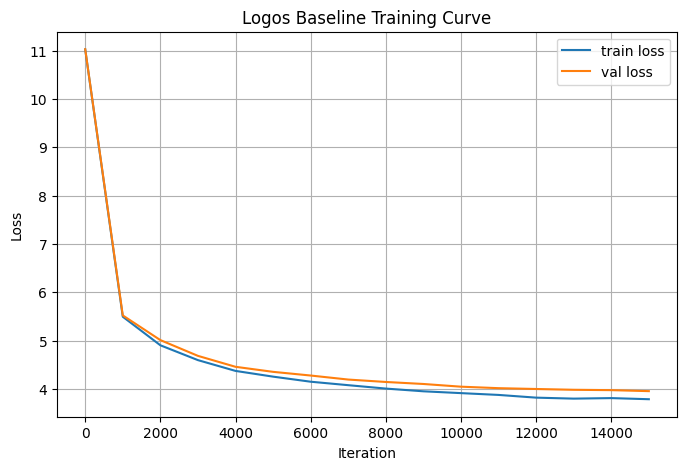

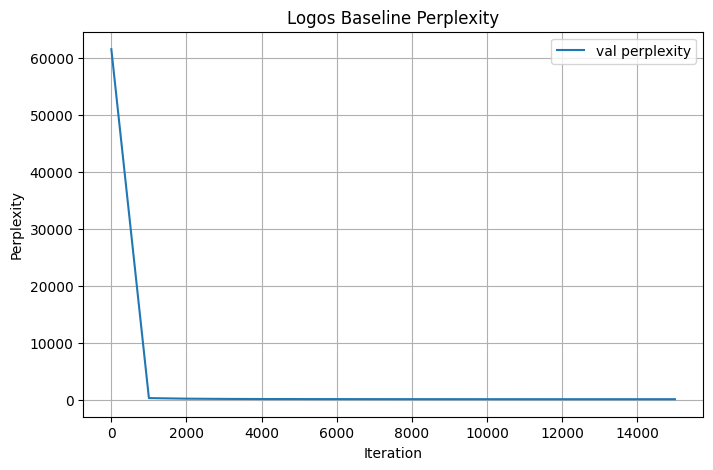

In [12]:
df = pd.read_csv(METRICS_PATH)

plt.figure(figsize=(8, 5))
plt.plot(df["iter"], df["train_loss"], label="train loss")
plt.plot(df["iter"], df["val_loss"], label="val loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Logos Baseline Training Curve")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["iter"], df["val_perplexity"], label="val perplexity")
plt.xlabel("Iteration")
plt.ylabel("Perplexity")
plt.title("Logos Baseline Perplexity")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# CELL 13 — Zip results for Experiment 18: Large Scaling + 15k Training

zip_path = shutil.make_archive(
    base_name="logos_exp18_large_scaling_weight_tying_swiglu_15k_train_results",
    format="zip",
    root_dir="./logos_runs",
    base_dir=RUN_NAME
)

print("Zipped results:", zip_path)

Zipped results: C:\Users\guest1\Desktop\projojo\logos_exp18_large_scaling_weight_tying_swiglu_15k_train_results.zip


In [21]:
# CELL 14 — Config for Experiment 19: Quantization and Compression of Experiment 18

EXP19_RUN_NAME = "logos_exp19_quantization_compression_exp18"

EXP19_OUT_DIR = Path("./logos_runs") / EXP19_RUN_NAME
EXP19_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Experiment 18 checkpoint path
EXP18_RUN_NAME = "logos_exp18_large_scaling_weight_tying_swiglu_15k_train"

EXP18_BEST_MODEL_PATH = (
    Path("./logos_runs")
    / EXP18_RUN_NAME
    / "logos_large_scaling_weight_tying_swiglu_15k_train_best.pt"
)

# Output paths
FP32_COPY_PATH = EXP19_OUT_DIR / "exp18_fp32_reference.pt"
FP16_PATH = EXP19_OUT_DIR / "exp18_fp16_checkpoint.pt"
INT8_DYNAMIC_STATE_PATH = EXP19_OUT_DIR / "exp18_dynamic_int8_cpu_state.pt"

EXP19_SUMMARY_PATH = EXP19_OUT_DIR / "quantization_summary.json"
EXP19_RESULTS_CSV = EXP19_OUT_DIR / "quantization_results.csv"

# Benchmark settings
QUANT_EVAL_ITERS_GPU = 30
QUANT_EVAL_ITERS_CPU = 10

GEN_PROMPT = "The future of language models"
GEN_TOKENS = 100

print("Experiment 19 output directory:", EXP19_OUT_DIR)
print("Experiment 18 checkpoint path:", EXP18_BEST_MODEL_PATH)

if not EXP18_BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Could not find checkpoint: {EXP18_BEST_MODEL_PATH}")

Experiment 19 output directory: logos_runs\logos_exp19_quantization_compression_exp18
Experiment 18 checkpoint path: logos_runs\logos_exp18_large_scaling_weight_tying_swiglu_15k_train\logos_large_scaling_weight_tying_swiglu_15k_train_best.pt


In [22]:
# CELL 15 — Helper functions for Experiment 19

import copy
import time
import json
import pandas as pd

def file_size_mb(path):
    path = Path(path)
    if not path.exists():
        return None
    return path.stat().st_size / (1024 ** 2)


def get_batch_for_device(split, batch_size, block_size, target_device):
    data = train_data if split == "train" else val_data

    ix = torch.randint(len(data) - block_size, (batch_size,))

    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])

    x = x.to(target_device)
    y = y.to(target_device)

    return x, y


@torch.no_grad()
def estimate_loss_for_model(
    eval_model,
    target_device,
    eval_iters=20,
    eval_batch_size=8,
    block_size=None
):
    eval_model.eval()

    if block_size is None:
        block_size = BLOCK_SIZE

    losses = {}

    for split in ["train", "val"]:
        split_losses = []

        for _ in range(eval_iters):
            xb, yb = get_batch_for_device(
                split=split,
                batch_size=eval_batch_size,
                block_size=block_size,
                target_device=target_device
            )

            _, loss = eval_model(xb, yb)
            split_losses.append(loss.item())

        losses[split] = sum(split_losses) / len(split_losses)

    return losses


@torch.no_grad()
def benchmark_generation_for_model(
    eval_model,
    target_device,
    prompt=GEN_PROMPT,
    max_new_tokens=GEN_TOKENS,
    temperature=0.9,
    top_k=40,
    top_p=0.9
):
    eval_model.eval()

    idx = torch.tensor(
        [enc.encode(prompt)],
        dtype=torch.long,
        device=target_device
    )

    # Warmup
    _ = eval_model.generate(
        idx,
        max_new_tokens=10,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p
    )

    if target_device == "cuda":
        torch.cuda.synchronize()

    start_time = time.time()

    out = eval_model.generate(
        idx,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p
    )

    if target_device == "cuda":
        torch.cuda.synchronize()

    elapsed = time.time() - start_time

    tokens_per_sec = max_new_tokens / elapsed
    ms_per_token = (elapsed / max_new_tokens) * 1000

    sample_text = enc.decode(out[0].tolist())

    return {
        "generation_tokens_per_sec": tokens_per_sec,
        "generation_ms_per_token": ms_per_token,
        "sample_text": sample_text,
    }


def count_parameters(model_obj):
    return sum(p.numel() for p in model_obj.parameters())


def save_fp16_checkpoint_from_fp32(checkpoint, output_path):
    fp16_state = {}

    for key, value in checkpoint["model_state_dict"].items():
        if torch.is_tensor(value) and value.is_floating_point():
            fp16_state[key] = value.half()
        else:
            fp16_state[key] = value

    fp16_checkpoint = {
        "model_state_dict": fp16_state,
        "source_checkpoint": str(EXP18_BEST_MODEL_PATH),
        "compression_type": "fp16_state_dict",
        "note": "Floating point tensors converted to FP16."
    }

    torch.save(fp16_checkpoint, output_path)
    return output_path


print("Helper functions ready.")

Helper functions ready.


In [23]:
# CELL 16 — Load FP32 reference model from Experiment 18

checkpoint_fp32 = torch.load(EXP18_BEST_MODEL_PATH, map_location="cpu")

# Uses the model class already defined in Cell 7.
# Make sure you have run Cell 7 before this cell.
model_fp32 = model.__class__().to(device)

model_fp32.load_state_dict(checkpoint_fp32["model_state_dict"])
model_fp32.to(device)
model_fp32.eval()

# Save a reference copy inside Experiment 19 folder
torch.save(
    {
        "model_state_dict": checkpoint_fp32["model_state_dict"],
        "source_checkpoint": str(EXP18_BEST_MODEL_PATH),
        "compression_type": "fp32_reference_copy"
    },
    FP32_COPY_PATH
)

fp32_param_count = count_parameters(model_fp32)
fp32_size_mb = file_size_mb(FP32_COPY_PATH)

print("Loaded FP32 reference model.")
print("Parameters:", f"{fp32_param_count:,}")
print("FP32 reference checkpoint size:", fp32_size_mb, "MB")

C:\Users\guest1\AppData\Local\Temp\ipykernel_4928\417720004.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_fp32 = torch.load(EXP18_BEST_MODEL_PATH, map_locat

Loaded FP32 reference model.
Parameters: 124,031,232
FP32 reference checkpoint size: 473.19574546813965 MB


In [24]:
# CELL 17 — Benchmark FP32 and FP16 checkpoints

results = []

# -------------------------
# FP32 GPU benchmark
# -------------------------
if device == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

fp32_losses = estimate_loss_for_model(
    eval_model=model_fp32,
    target_device=device,
    eval_iters=QUANT_EVAL_ITERS_GPU,
    eval_batch_size=8,
    block_size=BLOCK_SIZE
)

fp32_generation = benchmark_generation_for_model(
    eval_model=model_fp32,
    target_device=device,
    prompt=GEN_PROMPT,
    max_new_tokens=GEN_TOKENS,
    temperature=TEMPERATURE,
    top_k=TOP_K,
    top_p=TOP_P
)

fp32_peak_vram_mb = None
if device == "cuda":
    fp32_peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

results.append({
    "variant": "FP32_reference",
    "device": device,
    "param_count": fp32_param_count,
    "checkpoint_size_mb": fp32_size_mb,
    "train_loss_est": fp32_losses["train"],
    "val_loss_est": fp32_losses["val"],
    "val_ppl_est": math.exp(fp32_losses["val"]),
    "generation_tokens_per_sec": fp32_generation["generation_tokens_per_sec"],
    "generation_ms_per_token": fp32_generation["generation_ms_per_token"],
    "peak_vram_mb": fp32_peak_vram_mb,
})

print("FP32 benchmark complete.")
print(json.dumps(results[-1], indent=2))


# -------------------------
# FP16 checkpoint creation
# -------------------------
save_fp16_checkpoint_from_fp32(checkpoint_fp32, FP16_PATH)
fp16_size_mb = file_size_mb(FP16_PATH)

# Load FP16 model
model_fp16 = model.__class__().to(device)
fp16_checkpoint = torch.load(FP16_PATH, map_location="cpu")
model_fp16.load_state_dict(fp16_checkpoint["model_state_dict"])

if device == "cuda":
    model_fp16 = model_fp16.half().to(device)
else:
    model_fp16 = model_fp16.float().to(device)

model_fp16.eval()

if device == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

fp16_losses = estimate_loss_for_model(
    eval_model=model_fp16,
    target_device=device,
    eval_iters=QUANT_EVAL_ITERS_GPU,
    eval_batch_size=8,
    block_size=BLOCK_SIZE
)

fp16_generation = benchmark_generation_for_model(
    eval_model=model_fp16,
    target_device=device,
    prompt=GEN_PROMPT,
    max_new_tokens=GEN_TOKENS,
    temperature=TEMPERATURE,
    top_k=TOP_K,
    top_p=TOP_P
)

fp16_peak_vram_mb = None
if device == "cuda":
    fp16_peak_vram_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

results.append({
    "variant": "FP16_checkpoint",
    "device": device,
    "param_count": count_parameters(model_fp16),
    "checkpoint_size_mb": fp16_size_mb,
    "train_loss_est": fp16_losses["train"],
    "val_loss_est": fp16_losses["val"],
    "val_ppl_est": math.exp(fp16_losses["val"]),
    "generation_tokens_per_sec": fp16_generation["generation_tokens_per_sec"],
    "generation_ms_per_token": fp16_generation["generation_ms_per_token"],
    "peak_vram_mb": fp16_peak_vram_mb,
})

print("\nFP16 benchmark complete.")
print(json.dumps(results[-1], indent=2))

print("\n=== FP32 SAMPLE ===\n")
print(fp32_generation["sample_text"])

print("\n=== FP16 SAMPLE ===\n")
print(fp16_generation["sample_text"])

FP32 benchmark complete.
{
  "variant": "FP32_reference",
  "device": "cuda",
  "param_count": 124031232,
  "checkpoint_size_mb": 473.19574546813965,
  "train_loss_est": 3.7980512221654257,
  "val_loss_est": 3.993095842997233,
  "val_ppl_est": 54.22249411916938,
  "generation_tokens_per_sec": 105.55380651935,
  "generation_ms_per_token": 9.473841190338135,
  "peak_vram_mb": 6518.82421875
}


C:\Users\guest1\AppData\Local\Temp\ipykernel_4928\3952386851.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fp16_checkpoint = torch.load(FP16_PATH, map_location="cpu")


FP16 benchmark complete.
{
  "variant": "FP16_checkpoint",
  "device": "cuda",
  "param_count": 124031232,
  "checkpoint_size_mb": 310.2380886077881,
  "train_loss_est": 3.7924479166666667,
  "val_loss_est": 3.9296875,
  "val_ppl_est": 50.89107172411317,
  "generation_tokens_per_sec": 109.38176659351606,
  "generation_ms_per_token": 9.14229154586792,
  "peak_vram_mb": 5958.36083984375
}

=== FP32 SAMPLE ===

The future of language models and the future of religion is not enough, but with the help of the public sector, the future of language models, and future of languages in the United States.

The U.S. is looking to expand the world’s ability to provide more information about the future of languages and the future of language models. This could be the key to modernizing language models in the United States.

The U.S. is a new and improved language, with more than a few

=== FP16 SAMPLE ===

The future of language models is that it will be possible to get a better understanding of the

In [25]:
# CELL 18 — Dynamic INT8 CPU quantization benchmark

# Dynamic INT8 quantization is mainly useful for CPU inference.
# It quantizes Linear layers, but not embeddings, LayerNorm, or attention internals.
# This is still useful as a deployment-side compression test.

cpu_device = "cpu"

model_cpu_fp32 = model.__class__().to(cpu_device)
model_cpu_fp32.load_state_dict(checkpoint_fp32["model_state_dict"])
model_cpu_fp32.eval()

print("Creating dynamic INT8 quantized CPU model...")

model_int8 = torch.ao.quantization.quantize_dynamic(
    model_cpu_fp32,
    {nn.Linear},
    dtype=torch.qint8
)

model_int8.eval()

torch.save(
    {
        "model_state_dict": model_int8.state_dict(),
        "source_checkpoint": str(EXP18_BEST_MODEL_PATH),
        "compression_type": "dynamic_int8_cpu",
        "note": "Dynamic INT8 quantization applied to nn.Linear modules only."
    },
    INT8_DYNAMIC_STATE_PATH
)

int8_size_mb = file_size_mb(INT8_DYNAMIC_STATE_PATH)

print("Dynamic INT8 state saved.")
print("INT8 state size:", int8_size_mb, "MB")

# Use fewer eval iterations because CPU quantized evaluation may be slower.
int8_losses = estimate_loss_for_model(
    eval_model=model_int8,
    target_device=cpu_device,
    eval_iters=QUANT_EVAL_ITERS_CPU,
    eval_batch_size=2,
    block_size=BLOCK_SIZE
)

int8_generation = benchmark_generation_for_model(
    eval_model=model_int8,
    target_device=cpu_device,
    prompt=GEN_PROMPT,
    max_new_tokens=GEN_TOKENS,
    temperature=TEMPERATURE,
    top_k=TOP_K,
    top_p=TOP_P
)

results.append({
    "variant": "Dynamic_INT8_CPU",
    "device": "cpu",
    "param_count": count_parameters(model_int8),
    "checkpoint_size_mb": int8_size_mb,
    "train_loss_est": int8_losses["train"],
    "val_loss_est": int8_losses["val"],
    "val_ppl_est": math.exp(int8_losses["val"]),
    "generation_tokens_per_sec": int8_generation["generation_tokens_per_sec"],
    "generation_ms_per_token": int8_generation["generation_ms_per_token"],
    "peak_vram_mb": None,
})

print("\nDynamic INT8 CPU benchmark complete.")
print(json.dumps(results[-1], indent=2))

print("\n=== INT8 CPU SAMPLE ===\n")
print(int8_generation["sample_text"])

Creating dynamic INT8 quantized CPU model...
Dynamic INT8 state saved.
INT8 state size: 267.05133724212646 MB

Dynamic INT8 CPU benchmark complete.
{
  "variant": "Dynamic_INT8_CPU",
  "device": "cpu",
  "param_count": 39028992,
  "checkpoint_size_mb": 267.05133724212646,
  "train_loss_est": 3.769723415374756,
  "val_loss_est": 3.965983533859253,
  "val_ppl_est": 52.772147067205225,
  "generation_tokens_per_sec": 49.16180739649898,
  "generation_ms_per_token": 20.340993404388428,
  "peak_vram_mb": null
}

=== INT8 CPU SAMPLE ===

The future of language models is that we need to have more of a sense of the nature of a language and its significance.

The key of our approach is not the need for a language and it is the freedom of expression. It’s a powerful tool which allows us to find a way to communicate and communicate to those that are shared. The tools used by the people is to help them in solving problems that may be solved, which is why we can’t get into thinking and understanding 

In [26]:
# CELL 19 — Save Experiment 19 quantization results and zip outputs

results_df = pd.DataFrame(results)
results_df.to_csv(EXP19_RESULTS_CSV, index=False)

summary = {
    "run_name": EXP19_RUN_NAME,
    "source_experiment": "logos_exp18_large_scaling_weight_tying_swiglu_15k_train",
    "source_checkpoint": str(EXP18_BEST_MODEL_PATH),
    "task": "quantization_and_compression",
    "notes": {
        "fp16": "FP16 checkpoint stores floating point tensors in half precision.",
        "dynamic_int8_cpu": "Dynamic INT8 quantization applies mainly to nn.Linear modules and is intended for CPU inference.",
        "comparison_warning": "Validation estimates use sampled batches, so small differences may be noise."
    },
    "results": results
}

with open(EXP19_SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved results CSV:", EXP19_RESULTS_CSV)
print("Saved summary JSON:", EXP19_SUMMARY_PATH)

display(results_df)

zip_path = shutil.make_archive(
    base_name="logos_exp19_quantization_compression_results",
    format="zip",
    root_dir="./logos_runs",
    base_dir=EXP19_RUN_NAME
)

print("Zipped Experiment 19 results:", zip_path)

Saved results CSV: logos_runs\logos_exp19_quantization_compression_exp18\quantization_results.csv
Saved summary JSON: logos_runs\logos_exp19_quantization_compression_exp18\quantization_summary.json


,variant,device,param_count,checkpoint_size_mb,train_loss_est,val_loss_est,val_ppl_est,generation_tokens_per_sec,generation_ms_per_token,peak_vram_mb
0,FP32_reference,cuda,124031232,473.195745,3.798051,3.993096,54.222494,105.553807,9.473841,6518.824219
1,FP16_checkpoint,cuda,124031232,310.238089,3.792448,3.929688,50.891072,109.381767,9.142292,5958.360840
2,Dynamic_INT8_CPU,cpu,39028992,267.051337,3.769723,3.965984,52.772147,49.161807,20.340993,NaN


Zipped Experiment 19 results: C:\Users\guest1\Desktop\projojo\logos_exp19_quantization_compression_results.zip


In [27]:
# CELL 20 — Config for Experiment 20: Logos Efficiency Index

from pathlib import Path
import json
import math
import shutil
import pandas as pd
import matplotlib.pyplot as plt

EXP20_RUN_NAME = "logos_exp20_efficiency_index"

EXP20_OUT_DIR = Path("./logos_runs") / EXP20_RUN_NAME
EXP20_OUT_DIR.mkdir(parents=True, exist_ok=True)

EXP20_RESULTS_CSV = EXP20_OUT_DIR / "logos_efficiency_index_results.csv"
EXP20_SUMMARY_JSON = EXP20_OUT_DIR / "logos_efficiency_index_summary.json"

print("Experiment 20 output directory:", EXP20_OUT_DIR)

Experiment 20 output directory: logos_runs\logos_exp20_efficiency_index


In [28]:
# CELL 21 — Master table of Logos experiments

# Values collected from the completed Logos runs.
# Use final validation loss / final perplexity as the main benchmark numbers.

experiments = [
    {
        "experiment": "Baseline",
        "category": "baseline",
        "params_m": 32.159825,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7634,
        "ppl": 318.42,
        "checkpoint_mb": 122.71,
        "peak_vram_gb": 10.84,
        "latency_ms": 10.20,
        "energy_wh": 10.78,
    },
    {
        "experiment": "Exp01 Weight Tying",
        "category": "small_ablation",
        "params_m": 19.243776,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7693,
        "ppl": 320.32,
        "checkpoint_mb": 73.44,
        "peak_vram_gb": 10.69,
        "latency_ms": 12.64,
        "energy_wh": 9.87,
    },
    {
        "experiment": "Exp02 GELU",
        "category": "small_ablation",
        "params_m": 32.159825,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.8091,
        "ppl": 333.33,
        "checkpoint_mb": 122.71,
        "peak_vram_gb": 11.10,
        "latency_ms": 14.45,
        "energy_wh": 10.84,
    },
    {
        "experiment": "Exp03 RMSNorm",
        "category": "small_ablation",
        "params_m": 32.155473,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7722,
        "ppl": 321.24,
        "checkpoint_mb": 122.69,
        "peak_vram_gb": 11.11,
        "latency_ms": 13.51,
        "energy_wh": 11.50,
    },
    {
        "experiment": "Exp04 SwiGLU",
        "category": "small_ablation",
        "params_m": 32.158449,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7555,
        "ppl": 315.93,
        "checkpoint_mb": 122.71,
        "peak_vram_gb": 11.33,
        "latency_ms": 7.78,
        "energy_wh": 11.37,
    },
    {
        "experiment": "Exp05 WT + SwiGLU",
        "category": "small_combined",
        "params_m": 19.242400,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7247,
        "ppl": 306.36,
        "checkpoint_mb": 73.44,
        "peak_vram_gb": 11.18,
        "latency_ms": 15.04,
        "energy_wh": 10.49,
    },
    {
        "experiment": "Exp06 WT + SwiGLU ctx512",
        "category": "context_test",
        "params_m": 19.307936,
        "dataset_samples": 10_000,
        "context": 512,
        "iters": 1500,
        "final_val_loss": 5.8448,
        "ppl": 345.43,
        "checkpoint_mb": 73.69,
        "peak_vram_gb": 11.18,
        "latency_ms": 13.62,
        "energy_wh": 10.72,
    },
    {
        "experiment": "Exp07 Deeper-Narrower",
        "category": "shape_test",
        "params_m": 29.875409,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.8030,
        "ppl": 331.29,
        "checkpoint_mb": 114.02,
        "peak_vram_gb": 11.11,
        "latency_ms": 13.65,
        "energy_wh": 11.97,
    },
    {
        "experiment": "Exp08 Wider-Shallower",
        "category": "shape_test",
        "params_m": 33.065425,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7620,
        "ppl": 318.00,
        "checkpoint_mb": 126.15,
        "peak_vram_gb": 10.43,
        "latency_ms": 8.53,
        "energy_wh": 9.63,
    },
    {
        "experiment": "Exp09 Wider + WT + SwiGLU",
        "category": "small_efficiency",
        "params_m": 18.542688,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.7490,
        "ppl": 313.87,
        "checkpoint_mb": 70.76,
        "peak_vram_gb": 10.54,
        "latency_ms": 12.71,
        "energy_wh": 9.06,
    },
    {
        "experiment": "Exp10 Clean Data",
        "category": "data_test",
        "params_m": 18.542688,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 1500,
        "final_val_loss": 5.8246,
        "ppl": 338.53,
        "checkpoint_mb": 70.76,
        "peak_vram_gb": 10.54,
        "latency_ms": 8.65,
        "energy_wh": 8.98,
    },
    {
        "experiment": "Exp11 WT + SwiGLU 3k",
        "category": "longer_train",
        "params_m": 19.242400,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 3000,
        "final_val_loss": 5.3123,
        "ppl": 202.82,
        "checkpoint_mb": 73.45,
        "peak_vram_gb": 11.18,
        "latency_ms": 14.03,
        "energy_wh": 19.48,
    },
    {
        "experiment": "Exp12 Wider + WT + SwiGLU 3k",
        "category": "longer_train",
        "params_m": 18.542688,
        "dataset_samples": 10_000,
        "context": 256,
        "iters": 3000,
        "final_val_loss": 5.3470,
        "ppl": 210.00,
        "checkpoint_mb": 70.76,
        "peak_vram_gb": 10.54,
        "latency_ms": 12.06,
        "energy_wh": 16.29,
    },
    {
        "experiment": "Exp13 Medium Scaling",
        "category": "scaling",
        "params_m": 51.202896,
        "dataset_samples": 50_000,
        "context": 512,
        "iters": 3000,
        "final_val_loss": 5.0421,
        "ppl": 154.79,
        "checkpoint_mb": 195.36,
        "peak_vram_gb": 13.09,
        "latency_ms": 13.19,
        "energy_wh": 29.70,
    },
    {
        "experiment": "Exp14 Large Scaling",
        "category": "scaling",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 3000,
        "final_val_loss": 4.9244,
        "ppl": 137.60,
        "checkpoint_mb": 473.20,
        "peak_vram_gb": 17.73,
        "latency_ms": 15.13,
        "energy_wh": 59.76,
    },
    {
        "experiment": "Exp15 Large 5k",
        "category": "scaling",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 5000,
        "final_val_loss": 4.4663,
        "ppl": 87.03,
        "checkpoint_mb": 473.20,
        "peak_vram_gb": 17.73,
        "latency_ms": 16.76,
        "energy_wh": 96.03,
    },
    {
        "experiment": "Exp16 Large 7.5k",
        "category": "scaling",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 7500,
        "final_val_loss": 4.2254,
        "ppl": 68.40,
        "checkpoint_mb": 473.20,
        "peak_vram_gb": 17.73,
        "latency_ms": 11.92,
        "energy_wh": 141.11,
    },
    {
        "experiment": "Exp17 Large 10k",
        "category": "scaling",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 10_000,
        "final_val_loss": 4.1167,
        "ppl": 61.36,
        "checkpoint_mb": 473.20,
        "peak_vram_gb": 17.73,
        "latency_ms": 14.77,
        "energy_wh": 183.67,
    },
    {
        "experiment": "Exp18 Large 15k",
        "category": "scaling",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 15_000,
        "final_val_loss": 3.9811,
        "ppl": 53.57,
        "checkpoint_mb": 473.20,
        "peak_vram_gb": 17.73,
        "latency_ms": 9.11,
        "energy_wh": 277.39,
    },
    {
        "experiment": "Exp19 FP16 Deployment",
        "category": "compression",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 15_000,
        "final_val_loss": 3.9297,
        "ppl": 50.89,
        "checkpoint_mb": 310.24,
        "peak_vram_gb": 5.958,
        "latency_ms": 9.14,
        "energy_wh": None,
    },
    {
        "experiment": "Exp19 INT8 CPU",
        "category": "compression",
        "params_m": 124.031232,
        "dataset_samples": 100_000,
        "context": 512,
        "iters": 15_000,
        "final_val_loss": 3.9660,
        "ppl": 52.77,
        "checkpoint_mb": 267.05,
        "peak_vram_gb": None,
        "latency_ms": 20.34,
        "energy_wh": None,
    },
]

df = pd.DataFrame(experiments)

print("Loaded experiments:", len(df))
display(df)

Loaded experiments: 21


,experiment,category,params_m,dataset_samples,context,iters,final_val_loss,ppl,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh
0,Baseline,baseline,32.159825,10000,256,1500,5.7634,318.42,122.71,10.840,10.20,10.78
1,Exp01 Weight Tying,small_ablation,19.243776,10000,256,1500,5.7693,320.32,73.44,10.690,12.64,9.87
2,Exp02 GELU,small_ablation,32.159825,10000,256,1500,5.8091,333.33,122.71,11.100,14.45,10.84
3,Exp03 RMSNorm,small_ablation,32.155473,10000,256,1500,5.7722,321.24,122.69,11.110,13.51,11.50
4,Exp04 SwiGLU,small_ablation,32.158449,10000,256,1500,5.7555,315.93,122.71,11.330,7.78,11.37
5,Exp05 WT + SwiGLU,small_combined,19.242400,10000,256,1500,5.7247,306.36,73.44,11.180,15.04,10.49
6,Exp06 WT + SwiGLU ctx512,context_test,19.307936,10000,512,1500,5.8448,345.43,73.69,11.180,13.62,10.72
7,Exp07 Deeper-Narrower,shape_test,29.875409,10000,256,1500,5.8030,331.29,114.02,11.110,13.65,11.97
8,Exp08 Wider-Shallower,shape_test,33.065425,10000,256,1500,5.7620,318.00,126.15,10.430,8.53,9.63
9,Exp09 Wider + WT + SwiGLU,small_efficiency,18.542688,10000,256,1500,5.7490,313.87,70.76,10.540,12.71,9.06


In [29]:
# CELL 22 — Calculate Logos Efficiency Index

score_df = df.copy()

# For metrics where lower is better, normalize using best / current.
# This keeps every score between 0 and 1, where higher is better.

best_ppl = score_df["ppl"].min()
best_checkpoint = score_df["checkpoint_mb"].min()
best_vram = score_df["peak_vram_gb"].dropna().min()
best_latency = score_df["latency_ms"].min()
best_energy = score_df["energy_wh"].dropna().min()
best_params = score_df["params_m"].min()

score_df["quality_score"] = best_ppl / score_df["ppl"]
score_df["checkpoint_score"] = best_checkpoint / score_df["checkpoint_mb"]
score_df["vram_score"] = best_vram / score_df["peak_vram_gb"]
score_df["latency_score"] = best_latency / score_df["latency_ms"]
score_df["energy_score"] = best_energy / score_df["energy_wh"]
score_df["parameter_score"] = best_params / score_df["params_m"]

# Deployment-focused score:
# Best for deciding which model is most useful during inference/deployment.
# Does not include training energy because compression variants do not have training energy.
score_df["deployment_lei"] = (
    0.45 * score_df["quality_score"] +
    0.20 * score_df["checkpoint_score"] +
    0.15 * score_df["vram_score"].fillna(0) +
    0.15 * score_df["latency_score"] +
    0.05 * score_df["parameter_score"]
)

# Training-aware score:
# Useful for comparing trained models only.
# Compression rows are excluded from this ranking if energy is missing.
score_df["training_aware_lei"] = (
    0.40 * score_df["quality_score"] +
    0.15 * score_df["checkpoint_score"] +
    0.10 * score_df["vram_score"].fillna(0) +
    0.10 * score_df["latency_score"] +
    0.10 * score_df["parameter_score"] +
    0.15 * score_df["energy_score"].fillna(0)
)

# Simple compact formula, useful for reporting as a secondary metric.
# Higher is better.
score_df["simple_lei"] = 1 / (
    score_df["final_val_loss"] *
    score_df["checkpoint_mb"] *
    score_df["latency_ms"]
)

# Rank all models
score_df["deployment_rank"] = score_df["deployment_lei"].rank(
    ascending=False,
    method="min"
).astype(int)

score_df["training_aware_rank"] = score_df["training_aware_lei"].rank(
    ascending=False,
    method="min"
).astype(int)

score_df["simple_lei_rank"] = score_df["simple_lei"].rank(
    ascending=False,
    method="min"
).astype(int)

# Sort by deployment score
score_df = score_df.sort_values("deployment_lei", ascending=False).reset_index(drop=True)

display(score_df)

,experiment,category,params_m,dataset_samples,context,iters,final_val_loss,ppl,checkpoint_mb,peak_vram_gb,...,vram_score,latency_score,energy_score,parameter_score,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
0,Exp19 FP16 Deployment,compression,124.031232,100000,512,15000,3.9297,50.89,310.24,5.958,...,1.000000,0.851204,NaN,0.149500,0.780772,0.634283,0.000090,1,1,14
1,Exp18 Large 15k,scaling,124.031232,100000,512,15000,3.9811,53.57,473.20,17.730,...,0.336041,0.854007,0.032373,0.149500,0.643377,0.541230,0.000058,2,6,16
2,Exp19 INT8 CPU,compression,124.031232,100000,512,15000,3.9660,52.77,267.05,NaN,...,NaN,0.382498,NaN,0.149500,0.551812,0.478695,0.000046,3,12,17
3,Exp12 Wider + WT + SwiGLU 3k,longer_train,18.542688,10000,256,3000,5.3470,210.00,70.76,10.540,...,0.565275,0.645108,0.551258,1.000000,0.540607,0.550660,0.000219,4,5,2
4,Exp17 Large 10k,scaling,124.031232,100000,512,10000,4.1167,61.36,473.20,17.730,...,0.336041,0.526743,0.048892,0.149500,0.540015,0.462740,0.000035,5,14,19
5,Exp10 Clean Data,data_test,18.542688,10000,256,1500,5.8246,338.53,70.76,10.540,...,0.565275,0.899422,1.000000,1.000000,0.537351,0.606600,0.000280,6,2,1
6,Exp16 Large 7.5k,scaling,124.031232,100000,512,7500,4.2254,68.40,473.20,17.730,...,0.336041,0.652685,0.063638,0.149500,0.520493,0.443401,0.000042,7,15,18
7,Exp11 WT + SwiGLU 3k,longer_train,19.242400,10000,256,3000,5.3123,202.82,73.45,11.180,...,0.532916,0.554526,0.460986,0.963637,0.516884,0.519127,0.000183,8,9,5
8,Exp09 Wider + WT + SwiGLU,small_efficiency,18.542688,10000,256,1500,5.7490,313.87,70.76,10.540,...,0.565275,0.612116,0.991170,1.000000,0.499570,0.581270,0.000193,9,3,3
9,Exp01 Weight Tying,small_ablation,19.243776,10000,256,1500,5.7693,320.32,73.44,10.690,...,0.557343,0.615506,0.909828,0.963568,0.488300,0.558191,0.000187,10,4,4


In [30]:
# CELL 23 — Top Logos models by ranking type

cols = [
    "experiment",
    "category",
    "ppl",
    "final_val_loss",
    "params_m",
    "checkpoint_mb",
    "peak_vram_gb",
    "latency_ms",
    "energy_wh",
    "deployment_lei",
    "training_aware_lei",
    "simple_lei",
    "deployment_rank",
    "training_aware_rank",
    "simple_lei_rank",
]

print("Top 10 by Deployment LEI")
display(
    score_df.sort_values("deployment_lei", ascending=False)[cols].head(10)
)

print("\nTop 10 by Training-Aware LEI")
display(
    score_df.sort_values("training_aware_lei", ascending=False)[cols].head(10)
)

print("\nTop 10 by Simple LEI")
display(
    score_df.sort_values("simple_lei", ascending=False)[cols].head(10)
)

print("\nBest pure quality model:")
display(
    score_df.sort_values("ppl", ascending=True)[cols].head(5)
)

print("\nSmallest checkpoint models:")
display(
    score_df.sort_values("checkpoint_mb", ascending=True)[cols].head(5)
)

print("\nFastest generation models:")
display(
    score_df.sort_values("latency_ms", ascending=True)[cols].head(5)
)

Top 10 by Deployment LEI


,experiment,category,ppl,final_val_loss,params_m,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
0,Exp19 FP16 Deployment,compression,50.89,3.9297,124.031232,310.24,5.958,9.14,NaN,0.780772,0.634283,0.000090,1,1,14
1,Exp18 Large 15k,scaling,53.57,3.9811,124.031232,473.20,17.730,9.11,277.39,0.643377,0.541230,0.000058,2,6,16
2,Exp19 INT8 CPU,compression,52.77,3.9660,124.031232,267.05,NaN,20.34,NaN,0.551812,0.478695,0.000046,3,12,17
3,Exp12 Wider + WT + SwiGLU 3k,longer_train,210.00,5.3470,18.542688,70.76,10.540,12.06,16.29,0.540607,0.550660,0.000219,4,5,2
4,Exp17 Large 10k,scaling,61.36,4.1167,124.031232,473.20,17.730,14.77,183.67,0.540015,0.462740,0.000035,5,14,19
5,Exp10 Clean Data,data_test,338.53,5.8246,18.542688,70.76,10.540,8.65,8.98,0.537351,0.606600,0.000280,6,2,1
6,Exp16 Large 7.5k,scaling,68.40,4.2254,124.031232,473.20,17.730,11.92,141.11,0.520493,0.443401,0.000042,7,15,18
7,Exp11 WT + SwiGLU 3k,longer_train,202.82,5.3123,19.242400,73.45,11.180,14.03,19.48,0.516884,0.519127,0.000183,8,9,5
8,Exp09 Wider + WT + SwiGLU,small_efficiency,313.87,5.7490,18.542688,70.76,10.540,12.71,9.06,0.499570,0.581270,0.000193,9,3,3
9,Exp01 Weight Tying,small_ablation,320.32,5.7693,19.243776,73.44,10.690,12.64,9.87,0.488300,0.558191,0.000187,10,4,4



Top 10 by Training-Aware LEI


,experiment,category,ppl,final_val_loss,params_m,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
0,Exp19 FP16 Deployment,compression,50.89,3.9297,124.031232,310.24,5.958,9.14,NaN,0.780772,0.634283,0.000090,1,1,14
5,Exp10 Clean Data,data_test,338.53,5.8246,18.542688,70.76,10.540,8.65,8.98,0.537351,0.606600,0.000280,6,2,1
8,Exp09 Wider + WT + SwiGLU,small_efficiency,313.87,5.7490,18.542688,70.76,10.540,12.71,9.06,0.499570,0.581270,0.000193,9,3,3
9,Exp01 Weight Tying,small_ablation,320.32,5.7693,19.243776,73.44,10.690,12.64,9.87,0.488300,0.558191,0.000187,10,4,4
3,Exp12 Wider + WT + SwiGLU 3k,longer_train,210.00,5.3470,18.542688,70.76,10.540,12.06,16.29,0.540607,0.550660,0.000219,4,5,2
1,Exp18 Large 15k,scaling,53.57,3.9811,124.031232,473.20,17.730,9.11,277.39,0.643377,0.541230,0.000058,2,6,16
10,Exp05 WT + SwiGLU,small_combined,306.36,5.7247,19.242400,73.44,11.180,15.04,10.49,0.473164,0.540763,0.000158,11,7,9
11,Exp06 WT + SwiGLU ctx512,context_test,345.43,5.8448,19.307936,73.69,11.180,13.62,10.72,0.471982,0.535068,0.000170,12,8,7
7,Exp11 WT + SwiGLU 3k,longer_train,202.82,5.3123,19.242400,73.45,11.180,14.03,19.48,0.516884,0.519127,0.000183,8,9,5
13,Exp08 Wider-Shallower,shape_test,318.00,5.7620,33.065425,126.15,10.430,8.53,9.63,0.434734,0.492436,0.000161,14,10,8



Top 10 by Simple LEI


...

,experiment,category,ppl,final_val_loss,params_m,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
0,Exp19 FP16 Deployment,compression,50.89,3.9297,124.031232,310.24,5.958,9.14,NaN,0.780772,0.634283,0.000090,1,1,14
2,Exp19 INT8 CPU,compression,52.77,3.9660,124.031232,267.05,NaN,20.34,NaN,0.551812,0.478695,0.000046,3,12,17
1,Exp18 Large 15k,scaling,53.57,3.9811,124.031232,473.20,17.730,9.11,277.39,0.643377,0.541230,0.000058,2,6,16
4,Exp17 Large 10k,scaling,61.36,4.1167,124.031232,473.20,17.730,14.77,183.67,0.540015,0.462740,0.000035,5,14,19
6,Exp16 Large 7.5k,scaling,68.40,4.2254,124.031232,473.20,17.730,11.92,141.11,0.520493,0.443401,0.000042,7,15,18



Smallest checkpoint models:


,experiment,category,ppl,final_val_loss,params_m,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
3,Exp12 Wider + WT + SwiGLU 3k,longer_train,210.00,5.3470,18.542688,70.76,10.54,12.06,16.29,0.540607,0.550660,0.000219,4,5,2
5,Exp10 Clean Data,data_test,338.53,5.8246,18.542688,70.76,10.54,8.65,8.98,0.537351,0.606600,0.000280,6,2,1
8,Exp09 Wider + WT + SwiGLU,small_efficiency,313.87,5.7490,18.542688,70.76,10.54,12.71,9.06,0.499570,0.581270,0.000193,9,3,3
9,Exp01 Weight Tying,small_ablation,320.32,5.7693,19.243776,73.44,10.69,12.64,9.87,0.488300,0.558191,0.000187,10,4,4
10,Exp05 WT + SwiGLU,small_combined,306.36,5.7247,19.242400,73.44,11.18,15.04,10.49,0.473164,0.540763,0.000158,11,7,9



Fastest generation models:


,experiment,category,ppl,final_val_loss,params_m,checkpoint_mb,peak_vram_gb,latency_ms,energy_wh,deployment_lei,training_aware_lei,simple_lei,deployment_rank,training_aware_rank,simple_lei_rank
12,Exp04 SwiGLU,small_ablation,315.93,5.7555,32.158449,122.71,11.330,7.78,11.37,0.445524,0.479645,0.000182,13,11,6
13,Exp08 Wider-Shallower,shape_test,318.00,5.7620,33.065425,126.15,10.430,8.53,9.63,0.434734,0.492436,0.000161,14,10,8
5,Exp10 Clean Data,data_test,338.53,5.8246,18.542688,70.76,10.540,8.65,8.98,0.537351,0.606600,0.000280,6,2,1
1,Exp18 Large 15k,scaling,53.57,3.9811,124.031232,473.20,17.730,9.11,277.39,0.643377,0.541230,0.000058,2,6,16
0,Exp19 FP16 Deployment,compression,50.89,3.9297,124.031232,310.24,5.958,9.14,NaN,0.780772,0.634283,0.000090,1,1,14


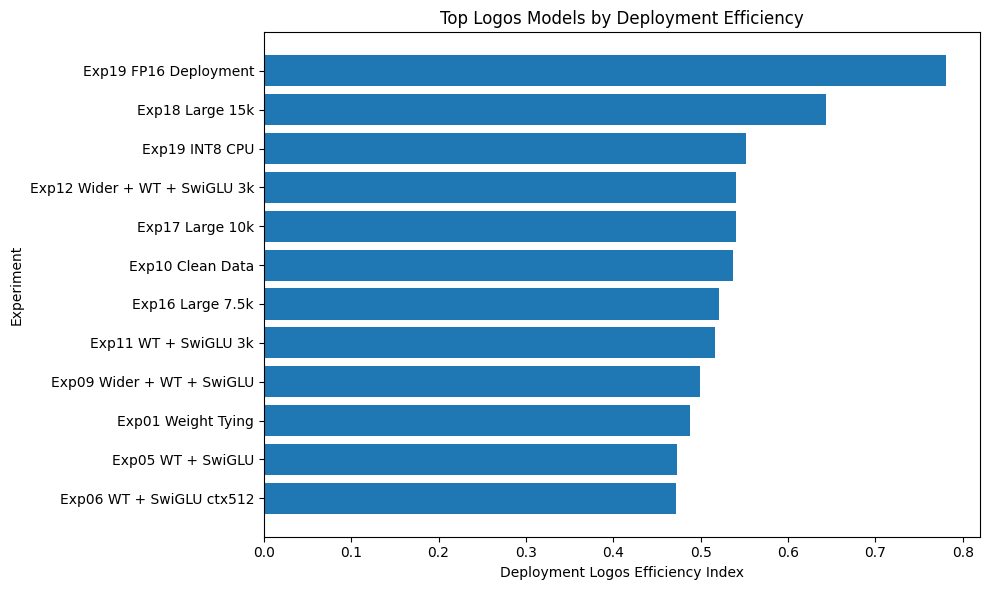

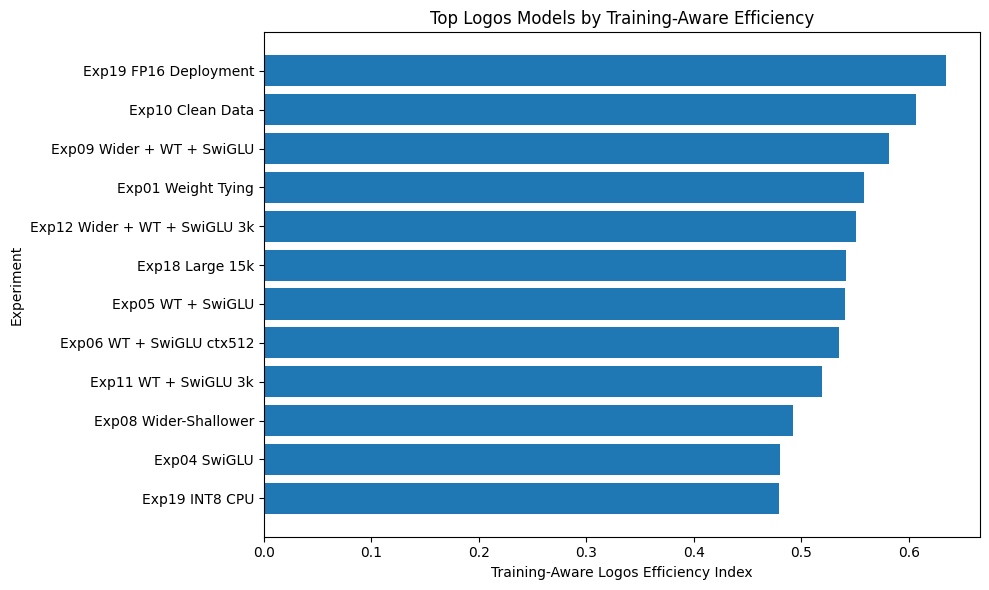

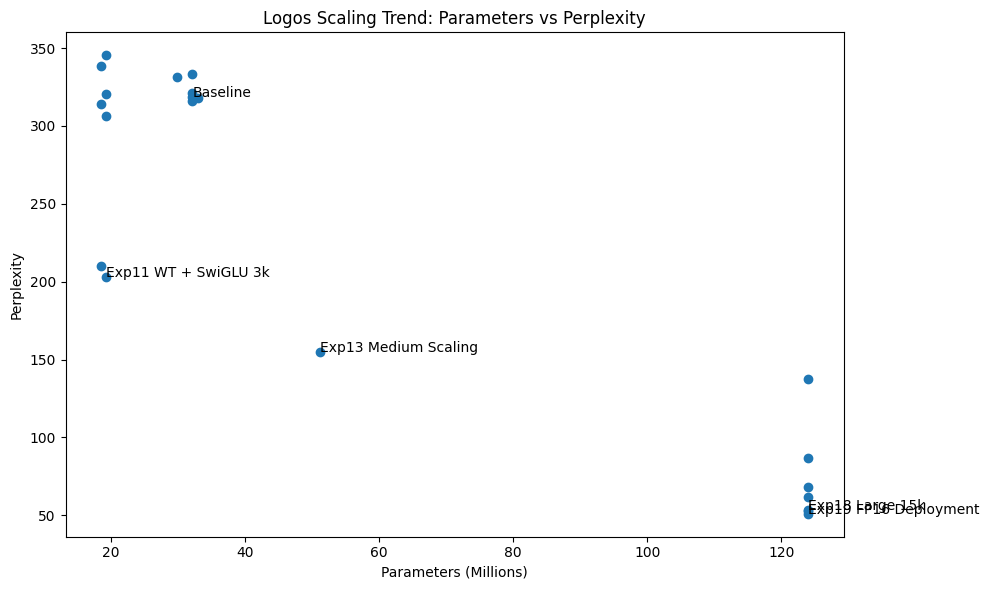

Saved plots:
logos_runs\logos_exp20_efficiency_index\deployment_lei_top_models.png
logos_runs\logos_exp20_efficiency_index\training_aware_lei_top_models.png
logos_runs\logos_exp20_efficiency_index\params_vs_perplexity.png


In [31]:
# CELL 24 — Visualize Logos Efficiency Index rankings

plot_df = score_df.sort_values("deployment_lei", ascending=True).tail(12)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["experiment"], plot_df["deployment_lei"])
plt.xlabel("Deployment Logos Efficiency Index")
plt.ylabel("Experiment")
plt.title("Top Logos Models by Deployment Efficiency")
plt.tight_layout()

deployment_plot_path = EXP20_OUT_DIR / "deployment_lei_top_models.png"
plt.savefig(deployment_plot_path, dpi=200)
plt.show()


plot_df2 = score_df.sort_values("training_aware_lei", ascending=True).tail(12)

plt.figure(figsize=(10, 6))
plt.barh(plot_df2["experiment"], plot_df2["training_aware_lei"])
plt.xlabel("Training-Aware Logos Efficiency Index")
plt.ylabel("Experiment")
plt.title("Top Logos Models by Training-Aware Efficiency")
plt.tight_layout()

training_plot_path = EXP20_OUT_DIR / "training_aware_lei_top_models.png"
plt.savefig(training_plot_path, dpi=200)
plt.show()


plot_df3 = score_df.sort_values("ppl", ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df3["params_m"], plot_df3["ppl"])
for _, row in plot_df3.iterrows():
    if row["experiment"] in [
        "Baseline",
        "Exp11 WT + SwiGLU 3k",
        "Exp13 Medium Scaling",
        "Exp18 Large 15k",
        "Exp19 FP16 Deployment",
    ]:
        plt.annotate(row["experiment"], (row["params_m"], row["ppl"]))

plt.xlabel("Parameters (Millions)")
plt.ylabel("Perplexity")
plt.title("Logos Scaling Trend: Parameters vs Perplexity")
plt.tight_layout()

scaling_plot_path = EXP20_OUT_DIR / "params_vs_perplexity.png"
plt.savefig(scaling_plot_path, dpi=200)
plt.show()

print("Saved plots:")
print(deployment_plot_path)
print(training_plot_path)
print(scaling_plot_path)

In [32]:
# CELL 25 — Save Experiment 20 results

score_df.to_csv(EXP20_RESULTS_CSV, index=False)

top_deployment = score_df.sort_values("deployment_lei", ascending=False).iloc[0].to_dict()
top_training = score_df.sort_values("training_aware_lei", ascending=False).iloc[0].to_dict()
top_quality = score_df.sort_values("ppl", ascending=True).iloc[0].to_dict()
top_checkpoint = score_df.sort_values("checkpoint_mb", ascending=True).iloc[0].to_dict()
top_latency = score_df.sort_values("latency_ms", ascending=True).iloc[0].to_dict()

summary = {
    "run_name": EXP20_RUN_NAME,
    "purpose": "Create Logos Efficiency Index rankings from completed experiments.",
    "score_definitions": {
        "quality_score": "best_ppl / model_ppl",
        "checkpoint_score": "smallest_checkpoint_mb / model_checkpoint_mb",
        "vram_score": "lowest_peak_vram_gb / model_peak_vram_gb",
        "latency_score": "fastest_latency_ms / model_latency_ms",
        "energy_score": "lowest_energy_wh / model_energy_wh",
        "parameter_score": "smallest_param_count / model_param_count",
        "deployment_lei": "0.45 quality + 0.20 checkpoint + 0.15 vram + 0.15 latency + 0.05 parameter",
        "training_aware_lei": "0.40 quality + 0.15 checkpoint + 0.10 vram + 0.10 latency + 0.10 parameter + 0.15 energy",
        "simple_lei": "1 / (val_loss * checkpoint_mb * latency_ms)"
    },
    "top_deployment_model": top_deployment,
    "top_training_aware_model": top_training,
    "top_quality_model": top_quality,
    "smallest_checkpoint_model": top_checkpoint,
    "fastest_latency_model": top_latency,
    "num_experiments_ranked": len(score_df),
}

with open(EXP20_SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("Saved CSV:", EXP20_RESULTS_CSV)
print("Saved summary:", EXP20_SUMMARY_JSON)

print("\nTop deployment model:")
print(top_deployment["experiment"])

print("\nTop training-aware model:")
print(top_training["experiment"])

print("\nTop quality model:")
print(top_quality["experiment"])

Saved CSV: logos_runs\logos_exp20_efficiency_index\logos_efficiency_index_results.csv
Saved summary: logos_runs\logos_exp20_efficiency_index\logos_efficiency_index_summary.json

Top deployment model:
Exp19 FP16 Deployment

Top training-aware model:
Exp19 FP16 Deployment

Top quality model:
Exp19 FP16 Deployment


In [33]:
# CELL 26 — Zip Experiment 20 results

zip_path = shutil.make_archive(
    base_name="logos_exp20_efficiency_index_results",
    format="zip",
    root_dir="./logos_runs",
    base_dir=EXP20_RUN_NAME
)

print("Zipped Experiment 20 results:", zip_path)

Zipped Experiment 20 results: C:\Users\guest1\Desktop\projojo\logos_exp20_efficiency_index_results.zip
